<a href="https://colab.research.google.com/github/imrannadaf250/code-python/blob/main/Data_Practice_D1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [7]:
df = pd.read_csv("/content/retail_sales_dataset.csv")

In [8]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [9]:
df.shape

(1000, 9)

In [10]:
df.columns

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='object')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [12]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [13]:
df.isnull().sum()

,0
Transaction ID,0
Date,0
Customer ID,0
Gender,0
Age,0
Product Category,0
Quantity,0
Price per Unit,0
Total Amount,0


In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df['Total Amount'].mean()

np.float64(456.0)

In [16]:
df['Total Amount'].max()

2000

In [17]:
df['Total Amount'].min()

25

In [18]:
top_products = (
    df.groupby('Product Category')["Quantity"]
      .sum()
      .sort_values(ascending=False)
)

print(top_products.head(10))

Product Category
Clothing       894
Electronics    849
Beauty         771
Name: Quantity, dtype: int64


In [19]:
category_sales = (
    df.groupby("Product Category")["Total Amount"]
      .sum()
      .sort_values(ascending=False)
)

print(category_sales)

Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64


In [20]:
top_customers = (
    df.groupby("Customer ID")["Total Amount"]
      .sum()
      .sort_values(ascending=False)
)

print(top_customers.head())

Customer ID
CUST015    2000
CUST412    2000
CUST970    2000
CUST547    2000
CUST281    2000
Name: Total Amount, dtype: int64


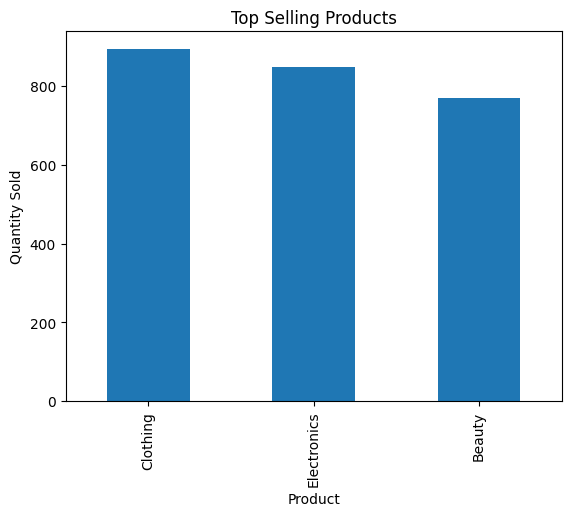

In [21]:
top_products.head(10).plot(kind="bar")

plt.title("Top Selling Products")
plt.xlabel("Product")
plt.ylabel("Quantity Sold")
plt.show()

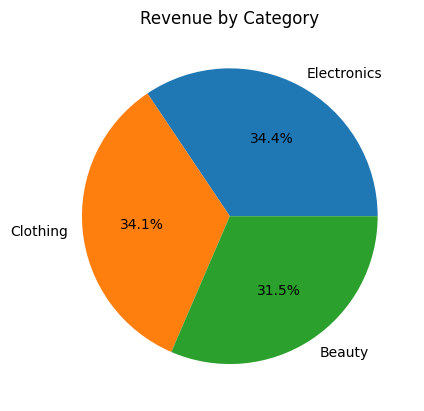

In [22]:
category_sales.plot(kind="pie", autopct="%1.1f%%")

plt.ylabel("")
plt.title("Revenue by Category")
plt.show()

In [23]:
df.sort_values(by="Total Amount", ascending=False).head(10)

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
945,946,2023-05-08,CUST946,Male,62,Electronics,4,500,2000
71,72,2023-05-23,CUST072,Female,20,Electronics,4,500,2000
14,15,2023-01-16,CUST015,Female,42,Electronics,4,500,2000
576,577,2023-02-13,CUST577,Male,21,Beauty,4,500,2000
571,572,2023-04-20,CUST572,Male,31,Clothing,4,500,2000
268,269,2023-02-01,CUST269,Male,25,Clothing,4,500,2000
502,503,2023-10-25,CUST503,Male,45,Beauty,4,500,2000
926,927,2023-06-24,CUST927,Male,43,Electronics,4,500,2000
252,253,2023-08-31,CUST253,Female,53,Clothing,4,500,2000
546,547,2023-03-07,CUST547,Male,63,Clothing,4,500,2000


In [24]:
df.groupby("Customer ID")["Total Amount"].sum().sort_values(ascending=False).head(10)

,Total Amount
Customer ID,
CUST015,2000
CUST412,2000
CUST970,2000
CUST547,2000
CUST281,2000
CUST416,2000
CUST420,2000
CUST927,2000
CUST447,2000


In [25]:
summary = (
    df.groupby("Product Category")
      .agg({
          "Price per Unit": "mean",
          "Quantity": "sum",
          "Total Amount": "sum"
      })
)

print(summary)

                  Price per Unit  Quantity  Total Amount
Product Category                                        
Beauty                184.055375       771        143515
Clothing              174.287749       894        155580
Electronics           181.900585       849        156905


In [26]:
top_products = (
    df.groupby("Product Category")["Total Amount"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(top_products)

Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64


In [27]:
pivot = pd.pivot_table(
    df,
    values="Total Amount",
    index="Gender",
    columns="Product Category",
    aggfunc="sum",
    fill_value=0
)

print(pivot)

Product Category  Beauty  Clothing  Electronics
Gender                                         
Female             74830     81275        76735
Male               68685     74305        80170


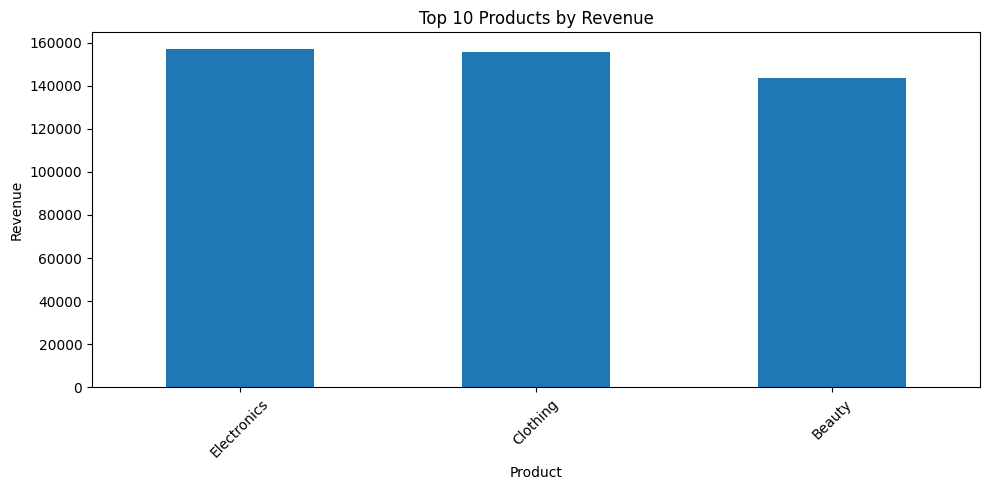

In [28]:
top_products = (
    df.groupby("Product Category")["Total Amount"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,5))
top_products.plot(kind="bar")

plt.title("Top 10 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

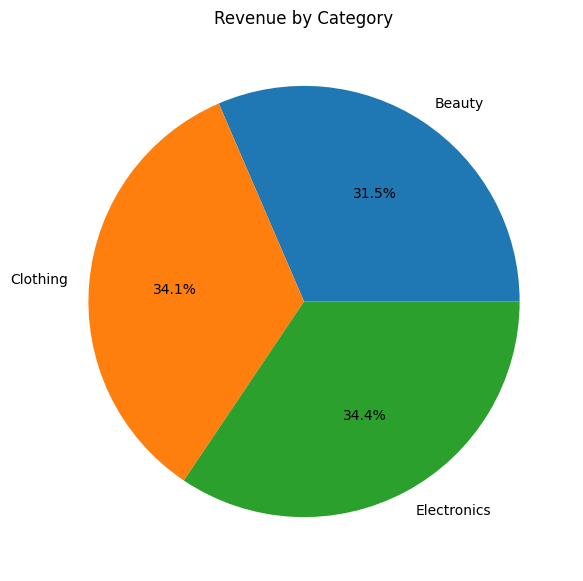

In [29]:
category_sales = (
    df.groupby("Product Category")["Total Amount"]
      .sum()
)

plt.figure(figsize=(7,7))
category_sales.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")
plt.title("Revenue by Category")
plt.show()

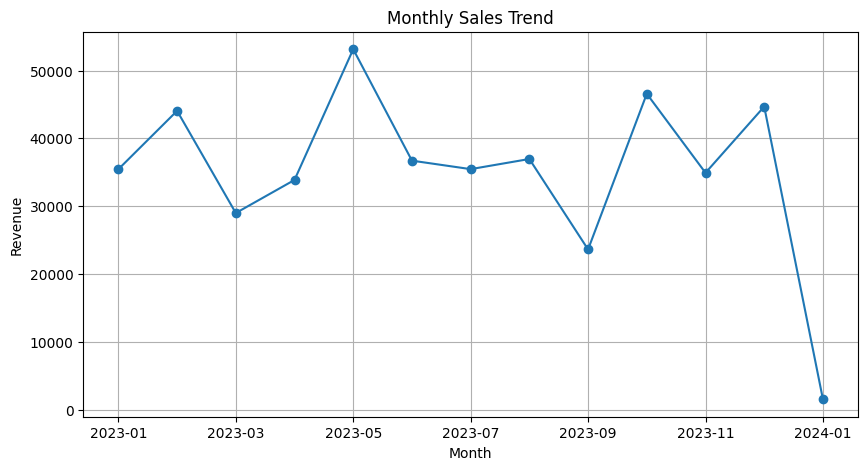

In [30]:
df["Date"] = pd.to_datetime(df["Date"])

monthly_sales = (
    df.groupby(df["Date"].dt.to_period("M"))["Total Amount"]
      .sum()
)

monthly_sales.index = monthly_sales.index.astype(str)

plt.figure(figsize=(10,5))
monthly_sales.plot(marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(True)
plt.show()

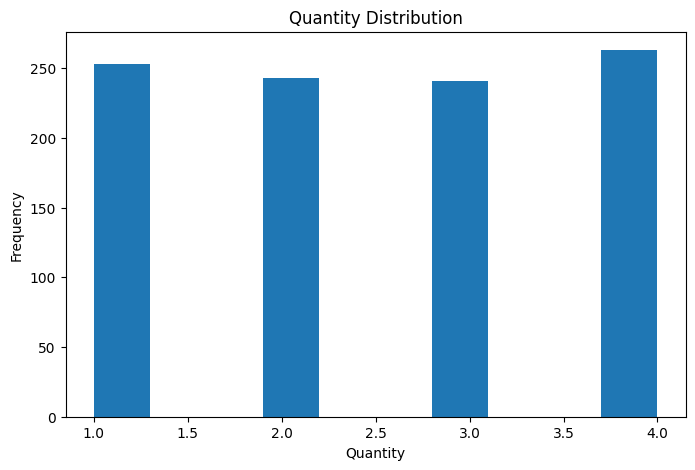

In [31]:
plt.figure(figsize=(8,5))

plt.hist(df["Quantity"], bins=10)

plt.title("Quantity Distribution")
plt.xlabel("Quantity")
plt.ylabel("Frequency")

plt.show()


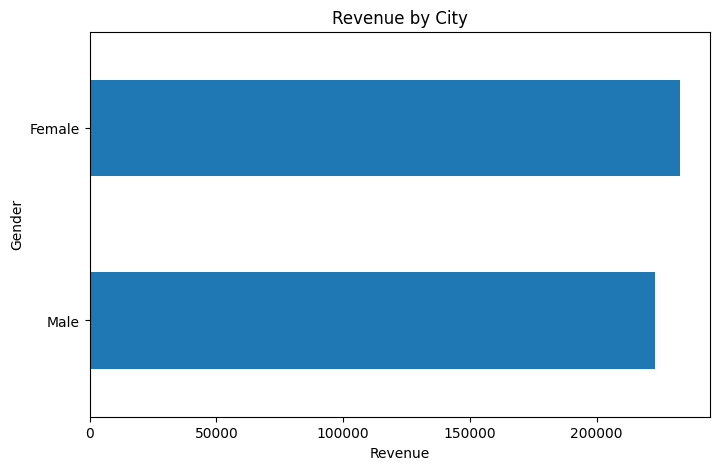

In [32]:
city_sales = (
    df.groupby("Gender")["Total Amount"]
      .sum()
      .sort_values()
)

plt.figure(figsize=(8,5))

city_sales.plot(kind="barh")

plt.title("Revenue by City")
plt.xlabel("Revenue")
plt.ylabel("Gender")

plt.show()

In [34]:
print("Total Revenue:", df["Total Amount"].sum())
print("Average Order Value:", df["Total Amount"].mean())
print("Unique Customers:", df["Customer ID"].nunique())
print("Unique Products:", df["Product Category"].nunique())

Total Revenue: 456000
Average Order Value: 456.0
Unique Customers: 1000
Unique Products: 3


In [37]:
pivot = pd.pivot_table(
    df,
    values="Total Amount",
    index="Gender",
    columns="Product Category",
    aggfunc=["sum", "mean"],
    fill_value=0
)

print(pivot)

                    sum                             mean              \
Product Category Beauty Clothing Electronics      Beauty    Clothing   
Gender                                                                 
Female            74830    81275       76735  450.783133  467.097701   
Male              68685    74305       80170  487.127660  419.802260   

                              
Product Category Electronics  
Gender                        
Female            451.382353  
Male              466.104651  


In [38]:
report = (
    df.groupby("Product Category")
      .agg({
          "Price per Unit": ["mean", "max", "min"],
          "Quantity": "sum",
          "Total Amount": ["sum", "mean"]
      })
)

print(report)

                 Price per Unit          Quantity Total Amount            
                           mean  max min      sum          sum        mean
Product Category                                                          
Beauty               184.055375  500  25      771       143515  467.475570
Clothing             174.287749  500  25      894       155580  443.247863
Electronics          181.900585  500  25      849       156905  458.786550


In [39]:
product_rank = (
    df.groupby("Product Category")["Total Amount"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

product_rank["Rank"] = range(1, len(product_rank) + 1)

print(product_rank.head(10))

  Product Category  Total Amount  Rank
0      Electronics        156905     1
1         Clothing        155580     2
2           Beauty        143515     3


In [40]:
customers = (
    df.groupby("Customer ID")["Total Amount"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(customers)

Customer ID
CUST015    2000
CUST412    2000
CUST970    2000
CUST547    2000
CUST281    2000
CUST416    2000
CUST420    2000
CUST927    2000
CUST447    2000
CUST342    2000
Name: Total Amount, dtype: int64


In [41]:
Q1 = df["Price per Unit"].quantile(0.25)
Q3 = df['Price per Unit'].quantile(0.75)

IQR = Q3 - Q1

outliers = df[
    (df["Price per Unit"] < Q1 - 1.5 * IQR) |
    (df["Price per Unit"] > Q3 + 1.5 * IQR)
]

print(outliers)

Empty DataFrame
Columns: [Transaction ID, Date, Customer ID, Gender, Age, Product Category, Quantity, Price per Unit, Total Amount]
Index: []
